In [3]:
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import torch
import seaborn as sns
from nrm.dataset.kinematics import inverse_kinematics
from matplotlib.ticker import MaxNLocator

import os
from matplotlib.lines import Line2D

from pathlib import Path

In [32]:
save_dir = Path.cwd() / "data"

In [33]:
mean_reachability_ours, lower_reachability_ours, upper_reachability_ours = pickle.load(
    open(save_dir / "ours" / "reachability.pkl", "rb"))
mean_deviation_ours, lower_deviation_ours, upper_deviation_ours = pickle.load(
    open(save_dir / "ours" / "deviation_loss.pkl", "rb"))
mean_reachability_base, lower_reachability_base, upper_reachability_base = pickle.load(
    open(save_dir / "base" / "reachability.pkl", "rb"))
mean_deviation_base, lower_deviation_base, upper_deviation_base = pickle.load(
    open(save_dir / "base" / "deviation_loss.pkl", "rb"))
mean_base_runtime, lower_base_runtime, upper_base_runtime = pickle.load(open(save_dir / "base_runtime.pkl", "rb"))
mean_ours_runtime, lower_ours_runtime, upper_ours_runtime = pickle.load(open(save_dir / "ours_runtime.pkl", "rb"))

In [34]:
mean_deviation_ours *= 2
lower_deviation_ours *= 2
upper_deviation_ours *= 2
mean_deviation_base *= 2
lower_deviation_base *= 2
upper_deviation_base *= 2

In [35]:
mean_pose_error_ours, lower_pose_error_ours, upper_pose_error_ours = pickle.load(
    open(save_dir / "ours" / "pose_error.pkl", "rb"))
mean_self_collision_ours, lower_self_collision_ours, upper_self_collision_ours = pickle.load(
    open(save_dir / "ours" / "self_collision.pkl", "rb"))
mean_pose_error_base, lower_pose_error_base, upper_pose_error_base = pickle.load(
    open(save_dir / "base" / "reachability.pkl", "rb"))
mean_self_collision_base, lower_self_collision_base, upper_self_collision_base = pickle.load(
    open(save_dir / "base" / "self_collision.pkl", "rb"))

/tmp/ipykernel_3291391/1338671108.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


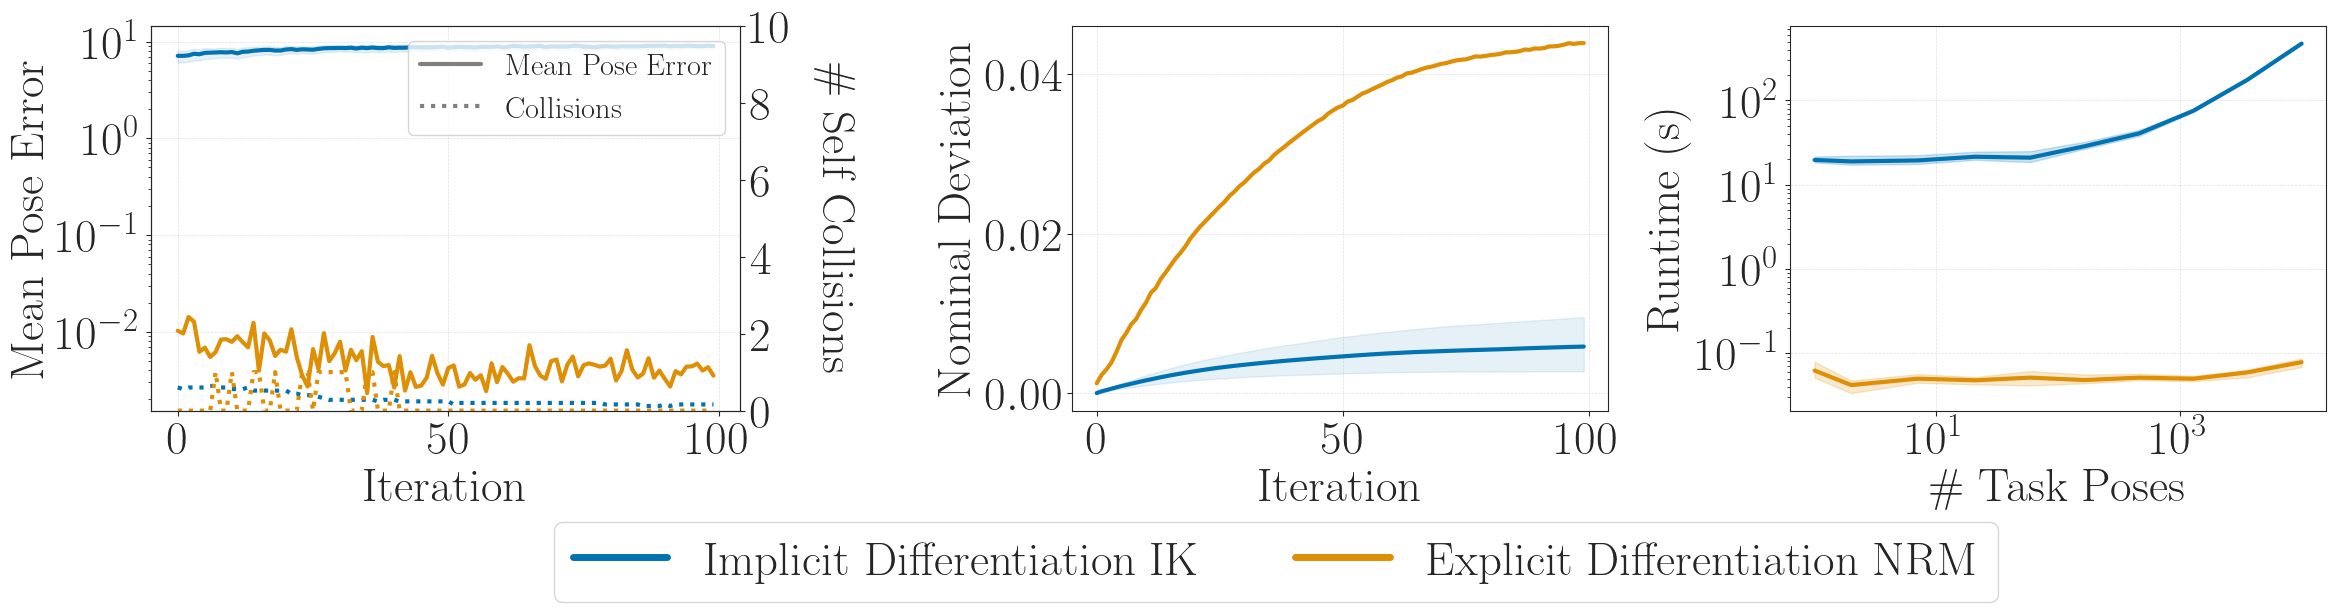

In [37]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import torch
import pickle
from matplotlib.lines import Line2D

# --- Style Configuration ---
sns.set_style("ticks")
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "pgf.rcfonts": False,
    "text.latex.preamble": r"\usepackage{amsmath}",

    "axes.labelsize": 34,
    "xtick.labelsize": 34,
    "ytick.labelsize": 34,
    "legend.fontsize": 34,
    "axes.titlesize": 34,
    "lines.linewidth": 3,
})

fig = plt.figure(figsize=(30, 5))

# 1. Create a GridSpec for the whole figure.
# We add extra width to the first column to "absorb" the twin axis label.
gs = fig.add_gridspec(1, 3, width_ratios=[1.1, 1, 1], wspace=0.6)

ax = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[0, 2])]
colors = sns.color_palette("colorblind", 4)
x = torch.arange(0, 100)

# ---------------------------------------------------------
# PLOT 1: POSE ERROR & SELF COLLISIONS (TWIN X)
# ---------------------------------------------------------
ax0_twin = ax[0].twinx()

ax[0].plot(x, mean_pose_error_base, color=colors[0], linestyle='-')
ax[0].plot(x, mean_pose_error_ours, color=colors[1], linestyle='-')
ax[0].fill_between(x, lower_pose_error_base, upper_pose_error_base, color=colors[0], alpha=0.1)
ax[0].fill_between(x, lower_pose_error_ours, upper_pose_error_ours, color=colors[1], alpha=0.1)
ax[0].set_ylabel(r"$\text{Mean Pose Error}$")
ax[0].set_yscale("log")
ax0_twin.plot(x, mean_self_collision_base, color=colors[0], linestyle=':')
ax0_twin.plot(x, mean_self_collision_ours, color=colors[1], linestyle=':')
ax0_twin.set_ylabel(r"$\text{\# Self Collisions}$", rotation=270, labelpad=45)
ax0_twin.set_ylim([0, 10])
ax0_twin.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=5))
ax[0].set_xlabel(r"$\text{Iteration}$")

# Style Legend for Plot 1
style_elements_p1 = [
    Line2D([0], [0], color='gray', linestyle='-', label=r"$\text{Mean Pose Error}$"),
    Line2D([0], [0], color='gray', linestyle=':', label=r"$\text{Collisions}$"),
]
ax[0].legend(handles=style_elements_p1, loc='upper right', fontsize=22)

# ---------------------------------------------------------
# PLOT 2: NOMINAL DEVIATION
# ---------------------------------------------------------
ax[1].plot(x, mean_deviation_base, color=colors[0])
ax[1].fill_between(x, lower_deviation_base, upper_deviation_base, color=colors[0], alpha=0.1)
ax[1].plot(x, mean_deviation_ours, color=colors[1])
ax[1].fill_between(x, lower_deviation_ours, upper_deviation_ours, color=colors[1], alpha=0.1)

ax[1].set_ylabel(r"$\text{Nominal Deviation}$")
ax[1].set_xlabel(r"$\text{Iteration}$")

# ---------------------------------------------------------
# PLOT 3: RUNTIME SCALING
# ---------------------------------------------------------
x_runtime = torch.logspace(0, 4, 10).int()
per_iteration = 100
ax[2].plot(x_runtime, mean_base_runtime / per_iteration, color=colors[0])
ax[2].fill_between(x_runtime, lower_base_runtime / per_iteration, upper_base_runtime / per_iteration, color=colors[0],
                   alpha=0.2)
ax[2].plot(x_runtime, mean_ours_runtime / per_iteration, color=colors[1])
ax[2].fill_between(x_runtime, lower_ours_runtime / per_iteration, upper_ours_runtime / per_iteration, color=colors[1],
                   alpha=0.2)

ax[2].set_ylabel(r"$\text{Runtime (s)}$")
ax[2].set_xlabel(r"$\text{\# Task Poses}$")
ax[2].set_yscale("log")
ax[2].set_xscale("log")

# --- CUSTOM UNEVEN SPACING ---
# We force the third plot to move closer to the second plot.
# Bbox: [left, bottom, width, height]
pos2 = ax[1].get_position()
pos3 = ax[2].get_position()

# Shift Plot 3 left by reducing the gap between 2 and 3
# Adjust the 0.05 value to bring them closer or further
ax[2].set_position([pos3.x0 - 0.05, pos3.y0, pos3.width, pos3.height])

# --- Global Polish ---
for i in range(3):
    ax[i].grid(True, linestyle='--', alpha=0.6)

method_elements = [
    Line2D([0], [0], color=colors[0], lw=5, label=r"$\text{Implicit Differentiation IK}$"),
    Line2D([0], [0], color=colors[1], lw=5, label=r"$\text{Explicit Differentiation NRM }$")
]

fig.legend(
    handles=method_elements,
    loc='lower center',
    ncol=2,
    bbox_to_anchor=(0.5, -0.32)
)

# Avoid tight_layout() here as it will override our manual set_position calls
plt.savefig("motion_planning.pdf", format="pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()

In [47]:
save_dir = Path(os.getcwd()) / "data" / "ours"
morph = pickle.load(open(save_dir / "morph.pkl", "rb"))
target_trajectory = pickle.load(open(save_dir / "target_trajectory.pkl", "rb"))
trajectory = pickle.load(open(save_dir / "trajectory.pkl", "rb"))
last_reachability = pickle.load(open(save_dir / "last_reachability.pkl", "rb"))
base_trajectory = pickle.load(open(Path(os.getcwd()) / "data" / "base" / "trajectory.pkl", "rb"))
base_reachability = pickle.load(open(Path(os.getcwd()) / "data" / "base" / "last_reachability.pkl", "rb"))

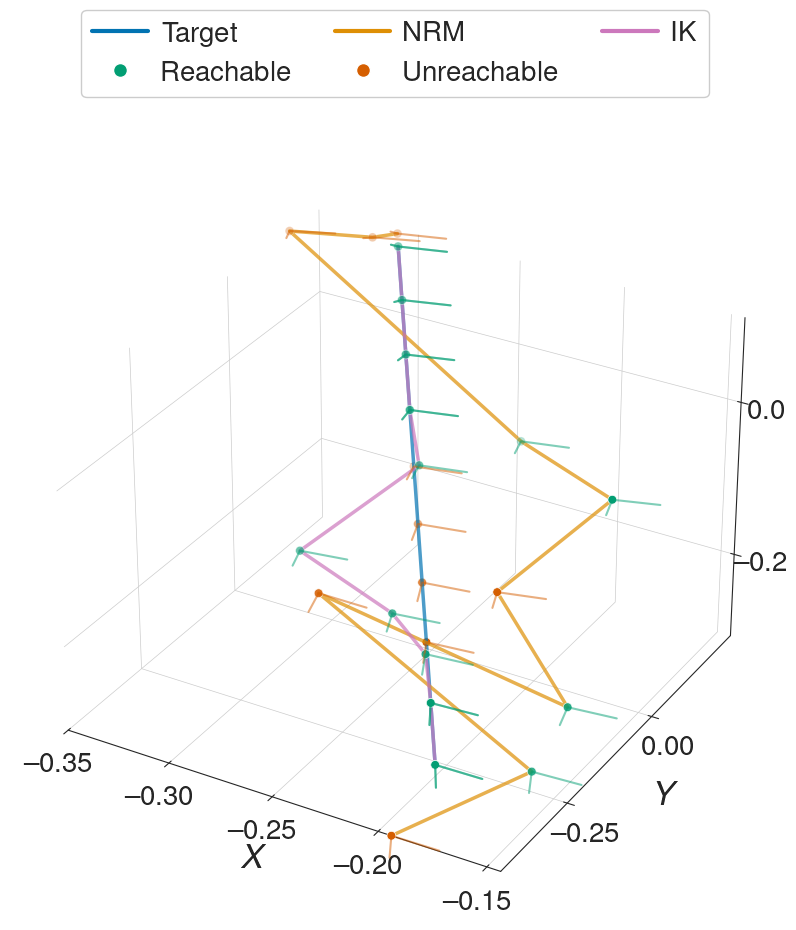

In [86]:
trajectories = [target_trajectory.cpu(), trajectory.cpu(), base_trajectory.cpu()]
labels = [true_reachability, last_reachability, base_reachability]
names = ["Target", "NRM", "IK"]

sns.set_style("ticks")
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "pgf.rcfonts": False,
    "text.latex.preamble": r"""
    \usepackage{amsmath}
    \usepackage{amssymb}
    \usepackage[T1]{fontenc}
    \usepackage{helvet}
    \renewcommand{\familydefault}{\sfdefault}
    \usepackage[italic]{mathastext} % Forces math to match the Helvetica text font
""",
    "font.size": 24,
    "axes.labelsize": 24,
    "legend.fontsize": 20,
    "axes.unicode_minus": False,
})

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# --- Color Palette ---
palette_id = sns.color_palette("colorblind", n_colors=5)
color_reach = palette_id[2]  # Clean Green
color_unreach = palette_id[3]  # Clean Red


def get_robust_l_frame(poses, axis_len=0.025):
    origins = poses[:, :3, 3]
    z_axes = poses[:, :3, 2]
    x_axes = poses[:, :3, 0]

    z_ends = origins + (z_axes * axis_len)
    x_ends = origins + (x_axes * axis_len)

    segments = torch.stack([z_ends, origins, x_ends], dim=1)
    nans = torch.full((segments.shape[0], 1, 3), float('nan'), device=poses.device)
    line_data = torch.cat([segments, nans], dim=1).reshape(-1, 3).cpu().numpy()

    return line_data, origins.cpu().numpy()


all_origins = []

for idx, (t, l, n) in enumerate(zip(trajectories, labels, names)):
    id_color = palette_id[idx if idx not in [2, 3] else 4]

    # PATH (Identity)
    _, all_pts = get_robust_l_frame(t)
    all_origins.append(all_pts)

    ax.plot(all_pts[:, 0], all_pts[:, 1], all_pts[:, 2],
            color=id_color, linewidth=2.5, alpha=0.7, zorder=2)

    # REACHABLE
    if torch.any(l):
        r_lines, r_pts = get_robust_l_frame(t[l])
        ax.scatter(r_pts[:, 0], r_pts[:, 1], r_pts[:, 2],
                   color=color_reach, s=40, edgecolors='white', linewidth=0.5, zorder=11)
        ax.plot(r_lines[:, 0], r_lines[:, 1], r_lines[:, 2],
                color=color_reach, linewidth=1.5, alpha=0.5, zorder=10)

    # UNREACHABLE
    if torch.any(~l):
        u_lines, u_pts = get_robust_l_frame(t[~l])
        ax.scatter(u_pts[:, 0], u_pts[:, 1], u_pts[:, 2],
                   color=color_unreach, s=40, edgecolors='white', linewidth=0.5, zorder=11)
        ax.plot(u_lines[:, 0], u_lines[:, 1], u_lines[:, 2],
                color=color_unreach, linewidth=1.5, alpha=0.5, zorder=10)

# --- DYNAMIC TIGHT ZOOM ---
stacked_origins = np.vstack(all_origins)

# 1. Find the min and max for each axis independently
mins = stacked_origins.min(axis=0)
maxs = stacked_origins.max(axis=0)

# 2. Calculate the spread (range) for each axis
spreads = maxs - mins

# 3. Add 20% padding to each axis independently.
# If an axis has 0 spread (e.g. 2D motion), give it a minimum 5cm padding
padding = np.maximum(spreads * 0.2, 0.05) * 0
x_lims = [mins[0] - padding[0], maxs[0] - padding[0]]
y_lims = [mins[1] - padding[1], maxs[1] - padding[1]]
z_lims = [mins[2] - padding[2], maxs[2] - padding[2]]

ax.set_xlim(x_lims)
ax.set_ylim(y_lims)
ax.set_zlim(z_lims)
#
ax.set_xlim(x_lims)
ax.set_ylim(y_lims)
ax.set_zlim(z_lims)

# --- AESTHETICS ---
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.grid(True, color='#F0F0F0', alpha=0.8)

ax.set_xlabel(r"$X$", labelpad=10)
ax.set_ylabel(r"$Y$", labelpad=10)
ax.set_zlabel(r"$Z$", labelpad=10)

ax.tick_params(axis='both', which='both', labelsize=20)
plt.locator_params(axis='y', nbins=3)
plt.locator_params(axis='x', nbins=4)
plt.locator_params(axis='z', nbins=4)
# --- CUSTOM COMPOSITE LEGEND ---
custom_lines = []
for idx, n in enumerate(names):
    if idx == 1:
        custom_lines.append(Line2D([0], [0], marker='o', color='w',
                                   markerfacecolor=color_reach, markersize=10, label='Reachable'))
    if idx == 2:
        custom_lines.append(Line2D([0], [0], marker='o', color='w',
                                   markerfacecolor=color_unreach, markersize=10, label='Unreachable'))
    custom_lines.append(Line2D([0], [0], color=palette_id[idx if idx not in [2, 3] else 4], lw=3, label=n))

legend = ax.legend(handles=custom_lines, loc='upper center', bbox_to_anchor=(0.5, 1.2),
                   ncol=3, frameon=True, handletextpad=0.5, columnspacing=1.5)
legend.get_frame().set_alpha(None)
legend.get_frame().set_facecolor((0, 0, 0, 0.0))

#plt.savefig("motion_planning.png", transparent=True, bbox_inches='tight', dpi=300)
plt.show()

In [118]:
import plotly.io as pio
pio.renderers.default = "browser"

In [139]:
def get_robust_l_frame(poses, axis_len=0.05):
    origins = poses[:, :3, 3]
    z_axes = poses[:, :3, 2]
    x_axes = poses[:, :3, 0]

    z_ends = origins + (z_axes * axis_len)
    x_ends = origins + (x_axes * axis_len)

    segments = torch.stack([z_ends, origins, x_ends], dim=1)
    nans = torch.full((segments.shape[0], 1, 3), float('nan'), device=poses.device)
    line_data = torch.cat([segments, nans], dim=1).reshape(-1, 3).cpu().numpy()

    return line_data, origins.cpu().numpy()

In [144]:
import plotly.graph_objects as go
import numpy as np

# --- Colors & Setup ---
palette = ['#0173b2', '#de8f05', '#cc78bc']  # Target (Blue), NRM (Orange), IK (Pink)
color_reach = '#029e73'  # Green
color_unreach = '#d55e00'  # Red

fig = go.Figure()

# --- 1. Helper for Legend Order ---
# We add "dummy" traces first to define the legend order exactly
legend_items = [
    ("Target", palette[0], 'line'),
    ("NRM", palette[1], 'line'),
    ("IK", palette[2], 'line'),
    ("Reachable", color_reach, 'marker'),
    ("Unreachable", color_unreach, 'marker')
]

for name, color, mode in legend_items:
    if mode == 'line':
        fig.add_trace(go.Scatter3d(
            x=[None], y=[None], z=[None],
            mode='lines',
            line=dict(color=color, width=12),
            name=name
        ))
    else:
        fig.add_trace(go.Scatter3d(
            x=[None], y=[None], z=[None],
            mode='markers',
            marker=dict(color=color, size=20),
            name=name
        ))

# --- 2. Plotting the Actual Data ---
# Note: showlegend=False because we already defined them above
for idx, (t, l, n) in enumerate(zip(trajectories, labels, names)):
    id_color = palette[idx]
    _, origins = get_robust_l_frame(t)

    path_lines, origins = get_robust_l_frame(t)

    # Main Path
    fig.add_trace(go.Scatter3d(
        x=origins[:, 0], y=origins[:, 1], z=origins[:, 2],
        mode='lines',
        line=dict(color=id_color, width=10),
        showlegend=False
    ))

    # B. ORIENTATION INDICATORS (The L-frames for the main path)
    fig.add_trace(go.Scatter3d(
        x=path_lines[:, 0], y=path_lines[:, 1], z=path_lines[:, 2],
        mode='lines',
        line=dict(color=id_color, width=4),
        opacity=0.6,
        showlegend=False
    ))

    # Reachable Points
    if torch.any(l):
        r_lines, r_pts = get_robust_l_frame(t[l])
        fig.add_trace(go.Scatter3d(
            x=r_pts[:, 0], y=r_pts[:, 1], z=r_pts[:, 2],
            mode='markers',
            marker=dict(color=color_reach, size=6, opacity=0.8),
            showlegend=False
        ))

        # L-frames for reachable poses
        fig.add_trace(go.Scatter3d(
            x=r_lines[:, 0], y=r_lines[:, 1], z=r_lines[:, 2],
            mode='lines',
            line=dict(color=color_reach, width=4),
            opacity=0.4,
            showlegend=False
        ))

    # Unreachable Points
    if torch.any(~l):
        u_lines, u_pts = get_robust_l_frame(t[~l])
        fig.add_trace(go.Scatter3d(
            x=u_pts[:, 0], y=u_pts[:, 1], z=u_pts[:, 2],
            mode='markers',
            marker=dict(color=color_unreach, size=6, opacity=0.8),
            showlegend=False
        ))
        # L-frames for unreachable poses
        fig.add_trace(go.Scatter3d(
            x=u_lines[:, 0], y=u_lines[:, 1], z=u_lines[:, 2],
            mode='lines',
            line=dict(color=color_unreach, width=4),
            opacity=0.4,
            showlegend=False
        ))

# --- 3. Final Layout Fixes ---
# --- Layout & Aesthetics ---
fig.update_layout(
    template="simple_white",
    width=2000,
    height=500,
    scene=dict(
        xaxis=dict(
            title='<br><br>X',
            showgrid=True,  # Ensure grid is visible
            gridcolor='lightgrey',  # Color of the grid lines
            gridwidth=8,  # Thickness
            zeroline=True,  # Show the 0 line
            zerolinecolor='black',  # Distinct color for the origin
            nticks=5, backgroundcolor="rgba(0,0,0,0)",
            tickfont=dict(size=18, family="Arial", color="black"),
        ),
        yaxis=dict(
            title='Y',
            showgrid=True,
            gridcolor='lightgrey',
            gridwidth=8,
            zeroline=True,
            zerolinecolor='black',
            nticks=5, backgroundcolor="rgba(0,0,0,0)",
            tickfont=dict(size=18, family="Arial", color="black"),
        ),
        zaxis=dict(
            title='Z',
            showgrid=True,
            gridcolor='lightgrey',
            gridwidth=8,
            zeroline=True,
            zerolinecolor='black',
            nticks=5, backgroundcolor="rgba(0,0,0,0)",
            tickfont=dict(size=18, family="Arial", color="black"),
        ),
        # This removes the "background" color of the walls to match your clean look
        xaxis_showspikes=False,
        yaxis_showspikes=False,
        zaxis_showspikes=False,
        xaxis_title_font=dict(size=28, family="Arial"),
        yaxis_title_font=dict(size=28, family="Arial"),
        zaxis_title_font=dict(size=28, family="Arial"),
        aspectmode='manual',
        aspectratio=dict(x=1, y=4, z=1),  # Z is 50% longer than X and Y
        camera=
            {
                'center': {'x': 0, 'y': 0, 'z': 0},
                "eye":{"x": -2.402934340972093, "y": -0.14253797828641002, "z": 0.4892977953085054},
                'projection': {'type': 'perspective'},
                'up': {'x': 0, 'y': 0, 'z': 1}
            }

    ),
    legend=dict(
        orientation="h",  # Horizontal
        yanchor="top",
        y=0.85,  # Pushes it above the plot area
        xanchor="center",
        x=0.5,  # Centers it
        font=dict(size=36),  # Larger font
        itemsizing='constant',  # Keeps symbols large even if data points are small
        bgcolor="rgba(0,0,0,0)"  # Transparent background
    ),
    margin=dict(l=0, r=0, b=0, t=0)  # Tight margins
)
config = {
    'toImageButtonOptions': {
        'format': 'png',
        'filename': 'motion_planning_qualtitative',
        'height': 500,
        'width': 2000,
        'scale': 4
    }
}
fig.write_image("motion_planning_qualitative.pdf", width=2000, height=600)
fig.show(config=config)